In [7]:
import pandas as pd
import os
import sys
from sklearn import set_config
from sklearn.model_selection import train_test_split
import numpy as np

sys.path.append(os.path.abspath(os.path.join("..")))
set_config(transform_output="pandas")

pancreatic = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/panc_filtered.csv")
lung = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/lung_filtered.csv")
gastric = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/gastric_filtered.csv")
breast = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/breast_filtered.csv")

In [8]:
from sklearn.preprocessing import QuantileTransformer

def process_and_harvest(df, test_size=0.2):
    X = df.drop(columns=["Cancer"])
    columns = X.columns
    X = pd.DataFrame(np.log1p(X), columns=columns)
    y = df["Cancer"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    healthy_train = X_train.loc[y_train == 0]
    cancer_train = X_train.loc[y_train == 1]

    return healthy_train, cancer_train, X_test, y_test

h_pan, c_pan, testX_pan, testY_pan = process_and_harvest(pancreatic)
h_lung, c_lung, testX_lung, testY_lung = process_and_harvest(lung)
h_gastric, c_gastric, testX_gastric, testY_gastric = process_and_harvest(gastric)
h_breast, c_breast, testX_breast, testY_breast = process_and_harvest(breast)

master_control = pd.concat([h_pan, h_lung, h_gastric, h_breast])

qt = QuantileTransformer(output_distribution="normal", random_state=42)
master_control = qt.fit_transform(master_control)

cancers_and_tests = [[c_pan, testX_pan], [c_lung, testX_lung], [c_gastric, testX_gastric], [c_breast, testX_breast]] 
for i in range(len(cancers_and_tests)):
    cancers_and_tests[i][0] = qt.transform(cancers_and_tests[i][0])
    cancers_and_tests[i][1] = qt.transform(cancers_and_tests[i][1])

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (50). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
print(master_control.columns)

Index(['RFC2', 'HSPA6', 'PAX8', 'GUCA1A', 'THRA', 'PTPN21', 'CCL5', 'CYP2E1',
       'EPHB3', 'ESRRA',
       ...
       'RP11-945A11.2', 'CCDC63', 'RP11-495P10.6', 'LOC101929475',
       'RP11-1260E13.2', 'LOC389641', 'GALR3', 'NUS1P3', 'LIME1 /// ZGPAT',
       'LOC100505915'],
      dtype='object', length=21809)


In [ ]:
training = []
for c_t in cancers_and_tests:
    tr_df = pd.concat([master_control, c_t[0]], axis=0)
    training.append(tr_df)

pan_tr = training[0]
lung_tr = training[1]
gastric_tr = training[2]
breast_tr = training[3]

In [10]:

pan_h = pancreatic[pancreatic["Cancer"] == 0].copy()
pan_h["Source"] = "Pancreas"

lung_h = lung[lung["Cancer"] == 0].copy()
lung_h["Source"] = "Lung"

gastric_h = gastric[gastric["Cancer"] == 0].copy()
gastric_h["Source"] = "Gastric"

breast_h = breast[breast["Cancer"] == 0].copy()
breast_h["Source"] = "Breast"

control_df = pd.concat([pan_h, lung_h], ignore_index=True)

X_controls = control_df.drop(columns=["Cancer", "Source"])
y_controls = control_df["Cancer"]
sources = control_df["Source"]

X_controls_log = np.log1p(X_controls)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_controls_norm = qt.fit_transform(X_controls_log)

X_controls_final = pd.DataFrame(X_controls_norm, columns=X_controls.columns)

print(f"Master Control Shape: {X_controls_final.shape}")

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (22). n_quantiles is set to n_samples.
  warnings.warn(


Master Control Shape: (22, 21809)


In [11]:

y = pancreatic[["Cancer"]]
X = pancreatic.drop(columns=["Cancer"])
num_cols = X.select_dtypes(include=["number", "float"]).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

print(X.columns)
print(y.columns)

Index(['RFC2', 'HSPA6', 'PAX8', 'GUCA1A', 'THRA', 'PTPN21', 'CCL5', 'CYP2E1',
       'EPHB3', 'ESRRA',
       ...
       'RP11-945A11.2', 'CCDC63', 'RP11-495P10.6', 'LOC101929475',
       'RP11-1260E13.2', 'LOC389641', 'GALR3', 'NUS1P3', 'LIME1 /// ZGPAT',
       'LOC100505915'],
      dtype='object', length=21809)
Index(['Cancer'], dtype='object')


In [12]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(X_train[y_train["Cancer"] == 1], X_train[y_train["Cancer"] == 0], axis=0, equal_var=False)
p_val_series = pd.Series(p_value, index=X_train.columns).sort_values()
top_20_genes = list(p_val_series.head(20).index)
X_train = X_train[top_20_genes]
X_test = X_test[top_20_genes]
print(top_20_genes)
print(X_train)

['RP3-406A7.7', 'HINT1', 'CREB3L2', 'RBM43', 'CABLES1', 'RALY', 'HOPX', 'FBP1', 'MAPKBP1', 'LOC101928978', 'KDM5C', 'H2AFX', 'RP11-82L18.2', 'PTPRG-AS1', 'FOLR1', 'RIMS2', 'FFAR3 /// GPR42', 'OR10A5', 'SEC11C', 'GRB7']
    RP3-406A7.7  HINT1  CREB3L2   RBM43  CABLES1  RALY  HOPX  FBP1  MAPKBP1  \
21        33.30   0.00     4.10   43.12     0.01  1.92  2.14  3.61     0.01   
6        197.57   5.75   118.80   29.08    47.05  0.83  2.79  1.50     3.59   
16        79.74   0.01     3.02   72.99    27.04  3.17  0.41  1.11     0.00   
14       125.25   0.00    28.94   27.31    25.57  3.25  0.55  2.97     0.04   
17        40.83   0.98    37.92   96.68    37.61  1.46  0.00  3.31     0.00   
3        186.55   2.47   115.35   10.36    50.30  1.90  2.24  1.84     0.00   
23        83.38   0.02    37.55   58.91     6.30  3.43  0.13  3.34     0.00   
18        81.67   0.00    59.40  103.62     0.01  2.76  0.07  4.50     0.22   
20         1.91   0.00     1.31   94.81     0.02  3.25  1.23  2.53    

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from biotransformers import get_log_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

def create_pipeline(model, use_interactions=False):
    pipeline = [
        ("log_transformer", get_log_transformer()),
        ("scaler", StandardScaler())
    ]

    if use_interactions:
        pipeline.append(("interactions", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)))
        pipeline.append(("feature_selection", SelectKBest(score_func=f_classif, k=5)))

    pipeline.append(("model", model))

    return Pipeline(pipeline)

models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier()
}

lr_pipeline = create_pipeline(models["LogisticRegression"], use_interactions=False)
rf_pipeline = create_pipeline(models["RandomForest"])

In [14]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1"],
    "model__solver": ["liblinear"],
    "model__class_weight": ["balanced"]
}

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

pipelines = [lr_pipeline, rf_pipeline]
param_grids = [lr_param_grid, rf_param_grid]

In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
import numpy as np

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

def specificity_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    "recall": "recall",
    "specificity": make_scorer(specificity_score)
}

all_results = {}

for grid, model, pipeline in zip(param_grids, models.keys(), pipelines):
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=grid, 
        n_iter=20,
        cv=cv, 
        scoring=scoring, 
        refit="recall",
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    
    result = pd.DataFrame(search.cv_results_)
    best_rows = result.loc[result["mean_test_recall"].idxmax()]
    all_results[model] = best_rows

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_fu

In [16]:
lr_estimator = lr_pipeline.set_params(**all_results["LogisticRegression"]["params"])
rf_estimator = rf_pipeline.set_params(**all_results["RandomForest"]["params"])

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\USER\AppData

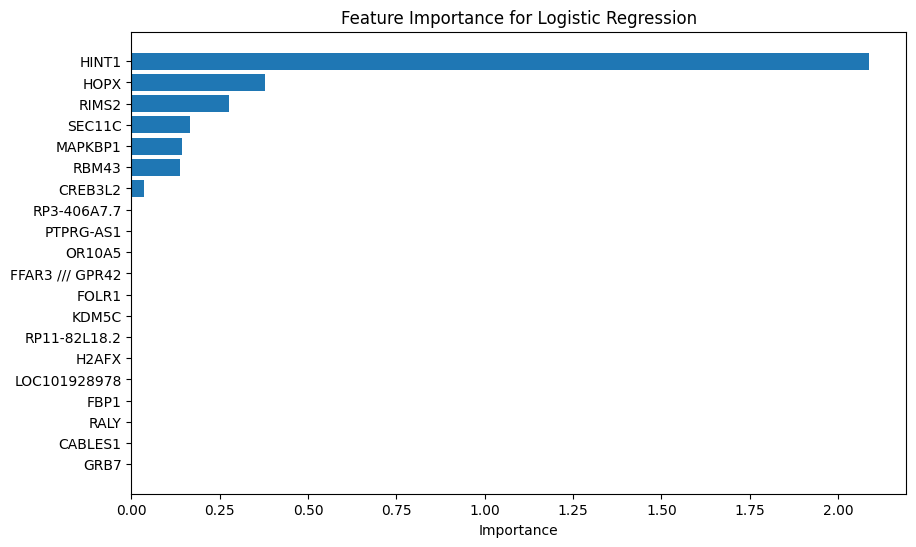

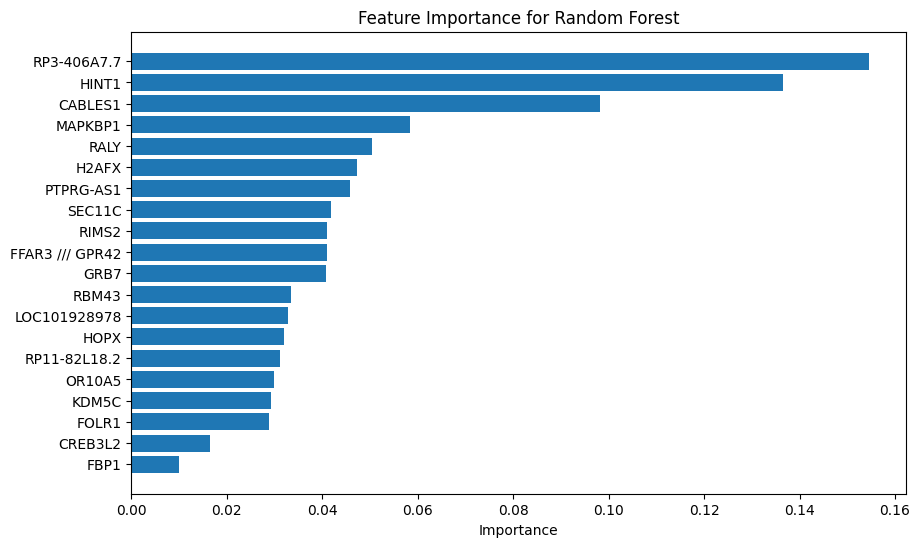

In [17]:
import matplotlib.pyplot as plt
from sklearn.base import clone

def create_feat_importance_df(estimator):
    if hasattr(estimator.named_steps["model"], "coef_"):
        importances = np.abs(estimator.named_steps["model"].coef_[0])
    
    elif hasattr(estimator.named_steps["model"], "feature_importances_"):
        importances = estimator.named_steps["model"].feature_importances_
    
    if "interactions" in estimator.named_steps:
        feature_names = estimator.named_steps["interactions"].get_feature_names_out(X_train.columns)

        if "feature_selection" in estimator.named_steps:
            selector = estimator.named_steps["feature_selection"]
            feature_names = feature_names[selector.get_support()]

    else:
        feature_names = estimator.feature_names_in_          
    
    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

def create_feat_importance_graph(importance_df, model_name):
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance for {model_name}")
    plt.gca().invert_yaxis()
    plt.show()

lr_fitted = lr_estimator.fit(X_train, y_train)
rf_fitted = rf_estimator.fit(X_train, y_train)

lr_importance_df = create_feat_importance_df(lr_fitted)
rf_importance_df = create_feat_importance_df(rf_fitted)

create_feat_importance_graph(lr_importance_df, "Logistic Regression")
create_feat_importance_graph(rf_importance_df, "Random Forest")

In [18]:
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, precision_score

y_pred_lr = lr_fitted.predict(X_test)
y_pred_rf = rf_fitted.predict(X_test)

print(f"Logistic Regression Classification Report:\n"
      f"{classification_report(y_test, y_pred_lr)}\n"
      f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n"
      f"Precision: {precision_score(y_test, y_pred_lr):.4f}\n"
      f"Recall: {recall_score(y_test, y_pred_lr):.4f}\n"
      f"F1: {f1_score(y_test, y_pred_lr):.4f}\n"
      f"Specificity: {specificity_score(y_test, y_pred_lr):.4f}\n"
      )

print(f"Random Forest Classification Report:\n"
      f"{classification_report(y_test, y_pred_rf)}\n"
      f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n"
      f"Precision: {precision_score(y_test, y_pred_rf):.4f}\n"
      f"Recall: {recall_score(y_test, y_pred_rf):.4f}\n"
      f"F1: {f1_score(y_test, y_pred_rf):.4f}\n"
      f"Specificity: {specificity_score(y_test, y_pred_rf):.4f}\n"
      )

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5

Accuracy: 0.6000
Precision: 0.5000
Recall: 0.5000
F1: 0.5000
Specificity: 0.6667

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5

Accuracy: 0.6000
Precision: 0.5000
Recall: 0.5000
F1: 0.5000
Specificity: 0.6667



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


In [19]:
print("--- Average CV Performance (The Real Comparison) ---")
for model_name, results in all_results.items():
    print(f"{model_name}:")
    print(f"  Mean Recall: {results['mean_test_recall']:.4f}")
    print(f"  Mean Specificity: {results['mean_test_specificity']:.4f}")

--- Average CV Performance (The Real Comparison) ---
LogisticRegression:
  Mean Recall: 0.9000
  Mean Specificity: 1.0000
RandomForest:
  Mean Recall: 1.0000
  Mean Specificity: 1.0000


In [20]:
for model_name, best_rows in all_results.items():
    print(f"Model: {model_name}")

    fold_recall_scores = [best_rows[f"split{i}_test_recall"] for i in range(cv.get_n_splits(X_train, y_train))]
    fold_specificity_scores = [best_rows[f"split{i}_test_specificity"] for i in range(cv.get_n_splits(X_train, y_train))]

    print(f"Recall across folds: {np.round(fold_recall_scores, 2)}")
    print(f"Mean: {np.mean(fold_recall_scores):.2f} | Std Dev: {np.std(fold_recall_scores):.2f}")
    
    zeros = fold_recall_scores.count(0)
    if zeros > 0:
        print(f"⚠️ Warning: Model completely failed to find cancer in {zeros} out of {len(fold_recall_scores)} folds.")

Model: LogisticRegression
Recall across folds: [1.  1.  1.  1.  1.  1.  1.  0.5 1.  1.  1.  0.  1.  1.  1. ]
Mean: 0.90 | Std Dev: 0.27
⚠️ Warning: Model completely failed to find cancer in 1 out of 15 folds.
Model: RandomForest
Recall across folds: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean: 1.00 | Std Dev: 0.00


In [21]:
# Instead of 0 or 1, let's look at the raw scores
y_probs_lr = lr_fitted.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Prediction Confidence ---")
for i, prob in enumerate(y_probs_lr):
    actual = y_test.iloc[i].values[0]
    print(f"Patient {i+1}: Actual={actual}, Probability of Cancer={prob:.2f}")

--- Logistic Regression Prediction Confidence ---
Patient 1: Actual=1, Probability of Cancer=0.93
Patient 2: Actual=1, Probability of Cancer=0.10
Patient 3: Actual=0, Probability of Cancer=0.14
Patient 4: Actual=0, Probability of Cancer=0.08
Patient 5: Actual=0, Probability of Cancer=0.94


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
